# Entrenamiento del modelo de detección — Semana 3

Detecta **6 patrones de velas japonesas** con Faster R-CNN y RetinaNet.
Se comparan 3 experimentos para manejar el desbalance de clases:

| # | Modelo | Estrategia |
|---|--------|------------|
| 1 | Faster R-CNN ResNet50-FPN | Baseline (sin balanceo) |
| 2 | Faster R-CNN ResNet50-FPN | WeightedRandomSampler |
| 3 | RetinaNet ResNet50-FPN | Focal Loss (nativa) |

## 1. Imports y configuración global

In [1]:
from pathlib import Path
from collections import Counter
import copy

import pandas as pd
import numpy as np
import yaml
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights,
    retinanet_resnet50_fpn, RetinaNet_ResNet50_FPN_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT           = Path("..")
DATA_ROOT      = ROOT / "data"
PROCESSED_ROOT = DATA_ROOT / "processed" / "dataset_no_background"
SPLIT_CSV = {
    "train": DATA_ROOT / "train.csv",
    "valid": DATA_ROOT / "val.csv",
    "test":  DATA_ROOT / "test.csv",
}

IMAGE_SIZE  = 224
BATCH_SIZE  = 4
NUM_EPOCHS  = 20
SEED        = 42
NUM_WORKERS = 0
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
plt.rcParams["figure.figsize"] = (12, 6)

Device: cuda


## 2. Dataset y DataLoaders para detección

In [2]:
# Leer clases desde data.yaml
with open(PROCESSED_ROOT / "data.yaml", "r", encoding="utf-8") as f:
    yaml_data = yaml.safe_load(f)
CLASS_NAMES = yaml_data["names"]
NUM_CLASSES = len(CLASS_NAMES)  # 6
# Faster R-CNN: background=0, clases 1-6
NUM_CLASSES_FRCNN    = NUM_CLASSES + 1   # 7
# RetinaNet: clases 0-5 (sin background explícito)
NUM_CLASSES_RETINANET = NUM_CLASSES      # 6
print(f"Clases ({NUM_CLASSES}):", CLASS_NAMES)

Clases (6): ['Bearish Engulfing', 'Bearish Insidebar', 'Bullish Engulfing', 'Bullish Insidebar', 'Hammer', 'Inverted_Hammer']


In [3]:
def convert_to_rgb(img: Image.Image) -> Image.Image:
    return img.convert("RGB") if img.mode != "RGB" else img


def read_yolo_annotations(label_path: Path) -> list:
    boxes = []
    if not label_path.exists():
        return boxes
    for line in label_path.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) >= 5:
            try:
                boxes.append((int(parts[0]),
                              float(parts[1]), float(parts[2]),
                              float(parts[3]), float(parts[4])))
            except ValueError:
                continue
    return boxes


def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    x2 = (xc + w / 2) * img_w
    y2 = (yc + h / 2) * img_h
    return [max(0.0, x1), max(0.0, y1), min(float(img_w), x2), min(float(img_h), y2)]


def detection_collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


class CandlestickDetectionDataset(Dataset):
    """Dataset para detección con boxes en formato Pascal VOC (x1,y1,x2,y2).

    label_offset=1  → Faster R-CNN (background=0, clases 1-N)
    label_offset=0  → RetinaNet   (clases 0 a N-1)
    """

    def __init__(self, csv_path: Path, dataset_root: Path,
                 transform=None, label_offset: int = 1):
        self.df           = pd.read_csv(csv_path)
        self.dataset_root = dataset_root
        self.transform    = transform
        self.label_offset = label_offset

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row        = self.df.iloc[idx]
        image_path = self.dataset_root / row["image"]
        label_path = self.dataset_root / row["label"]

        image = Image.open(image_path)
        image = convert_to_rgb(image)
        if self.transform is not None:
            image = self.transform(image)
        else:
            image = T.ToTensor()(image)

        W = H = IMAGE_SIZE
        annotations = read_yolo_annotations(label_path)

        if annotations:
            boxes_list, labels_list = [], []
            for cls_id, xc, yc, bw, bh in annotations:
                xyxy = yolo_to_xyxy(xc, yc, bw, bh, W, H)
                # Filtrar boxes degenerados
                if xyxy[2] > xyxy[0] and xyxy[3] > xyxy[1]:
                    boxes_list.append(xyxy)
                    labels_list.append(cls_id + self.label_offset)
            if boxes_list:
                boxes  = torch.tensor(boxes_list, dtype=torch.float32)
                labels = torch.tensor(labels_list, dtype=torch.int64)
            else:
                boxes  = torch.zeros((0, 4), dtype=torch.float32)
                labels = torch.zeros(0, dtype=torch.int64)
        else:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}
        return image, target


base_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
train_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Datasets e transforms definidos.")

Datasets e transforms definidos.


## 3. Análisis del desbalance de clases

Instancias por clase en train:
  [0] Bearish Engulfing           74
  [1] Bearish Insidebar          156
  [2] Bullish Engulfing          185
  [3] Bullish Insidebar          118
  [4] Hammer                     175
  [5] Inverted_Hammer            105


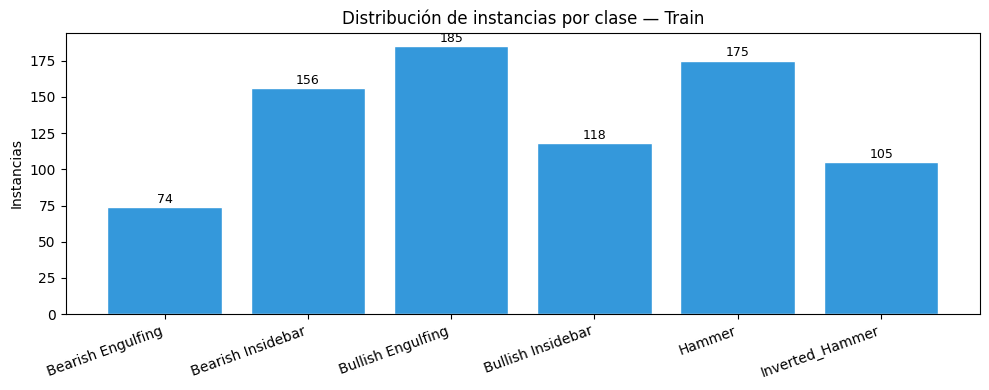

In [4]:
train_df = pd.read_csv(SPLIT_CSV["train"])

class_counts = Counter()
sample_primary_class = []   # clase principal de cada imagen (primera anotación)

for _, row in train_df.iterrows():
    anns = read_yolo_annotations(PROCESSED_ROOT / row["label"])
    for cls_id, *_ in anns:
        class_counts[cls_id] += 1
    primary = anns[0][0] if anns else 0
    sample_primary_class.append(primary)

print("Instancias por clase en train:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  [{i}] {name:<25} {class_counts[i]:>4}")

fig, ax = plt.subplots(figsize=(10, 4))
counts  = [class_counts[i] for i in range(NUM_CLASSES)]
bars    = ax.bar(CLASS_NAMES, counts, color="#3498db", edgecolor="white")
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha="center", va="bottom", fontsize=9)
ax.set_title("Distribución de instancias por clase — Train")
ax.set_ylabel("Instancias")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [5]:
# Pesos de clase por frecuencia inversa
total = sum(class_counts.values())
class_weights = torch.tensor(
    [total / (NUM_CLASSES * max(class_counts[i], 1)) for i in range(NUM_CLASSES)],
    dtype=torch.float32
)
print("Pesos de clase (inverso de frecuencia):")
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f"  [{i}] {name:<25} peso={w:.3f}")

# Pesos por muestra para WeightedRandomSampler
sample_weights = [class_weights[c].item() for c in sample_primary_class]
print(f"\nSample weights: min={min(sample_weights):.3f} | max={max(sample_weights):.3f}")

Pesos de clase (inverso de frecuencia):
  [0] Bearish Engulfing         peso=1.831
  [1] Bearish Insidebar         peso=0.869
  [2] Bullish Engulfing         peso=0.732
  [3] Bullish Insidebar         peso=1.148
  [4] Hammer                    peso=0.774
  [5] Inverted_Hammer           peso=1.290

Sample weights: min=0.732 | max=1.831


## 4. Definición del modelo y estrategia de fine-tuning

In [6]:
def build_faster_rcnn(num_classes: int):
    """Faster R-CNN ResNet50-FPN con backbone COCO. num_classes incluye background."""
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def build_retinanet(num_classes: int):
    """RetinaNet ResNet50-FPN con Focal Loss. num_classes sin background (0..N-1)."""
    model = retinanet_resnet50_fpn(weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1)
    num_anchors = model.head.classification_head.num_anchors
    in_channels = model.backbone.out_channels
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels, num_anchors, num_classes
    )
    return model


# Smoke-test rápido de shapes
with torch.no_grad():
    _m = build_faster_rcnn(NUM_CLASSES_FRCNN)
    _m.eval()
    _img = [torch.rand(3, IMAGE_SIZE, IMAGE_SIZE)]
    _out = _m(_img)
    print("Faster R-CNN OK — keys:", list(_out[0].keys()))
    del _m

    _r = build_retinanet(NUM_CLASSES_RETINANET)
    _r.eval()
    _out = _r(_img)
    print("RetinaNet OK    — keys:", list(_out[0].keys()))

Faster R-CNN OK — keys: ['boxes', 'labels', 'scores']
RetinaNet OK    — keys: ['boxes', 'scores', 'labels']


## 5. Loop de entrenamiento genérico

In [7]:
def train_detection_model(model, train_loader, valid_loader,
                          optimizer, scheduler, num_epochs,
                          device, exp_name):
    history = {"train_loss": [], "val_map": []}
    best_map, best_weights = 0.0, None
    out_path = ROOT / "dev" / f"{exp_name}_best.pth"

    epoch_bar = tqdm(range(1, num_epochs + 1), desc=exp_name, unit="epoch")

    for epoch in epoch_bar:
        # --- Train ---
        model.train()
        epoch_loss = 0.0
        batch_bar = tqdm(train_loader, desc=f"  Ep{epoch:>2} train", leave=False, unit="batch")
        for images, targets in batch_bar:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            valid = [i for i, t in enumerate(targets) if t["boxes"].shape[0] > 0]
            if not valid:
                continue
            images  = [images[i]  for i in valid]
            targets = [targets[i] for i in valid]

            loss_dict = model(images, targets)
            loss      = sum(loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            batch_bar.set_postfix(loss=f"{loss.item():.3f}")

        avg_loss = epoch_loss / max(len(train_loader), 1)
        history["train_loss"].append(avg_loss)

        # --- Validation ---
        model.eval()
        metric = MeanAveragePrecision(iou_type="bbox")
        with torch.no_grad():
            for images, targets in tqdm(valid_loader, desc=f"  Ep{epoch:>2} val  ", leave=False, unit="batch"):
                images = [img.to(device) for img in images]
                preds  = model(images)
                preds_cpu   = [{k: v.cpu() for k, v in p.items()} for p in preds]
                targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
                metric.update(preds_cpu, targets_cpu)

        result   = metric.compute()
        val_map  = result["map_50"].item()
        history["val_map"].append(val_map)

        if scheduler is not None:
            scheduler.step()

        if val_map > best_map:
            best_map     = val_map
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, out_path)

        epoch_bar.set_postfix(loss=f"{avg_loss:.4f}", mAP50=f"{val_map:.4f}", best=f"{best_map:.4f}")

    print(f"\n[{exp_name}] Mejor val_mAP@0.5 = {best_map:.4f} → {out_path}")
    model.load_state_dict(best_weights)
    return history

## 6. Experimento 1 — Baseline sin balanceo de clases

DataLoader con `shuffle=True`. Loss estándar de Faster R-CNN.
**Objetivo:** mostrar el impacto del desbalance — AP bajo en clases minoritarias.

In [8]:
train_ds_frcnn = CandlestickDetectionDataset(
    SPLIT_CSV["train"], PROCESSED_ROOT, transform=train_transform, label_offset=1)
valid_ds_frcnn = CandlestickDetectionDataset(
    SPLIT_CSV["valid"], PROCESSED_ROOT, transform=base_transform, label_offset=1)
test_ds_frcnn  = CandlestickDetectionDataset(
    SPLIT_CSV["test"],  PROCESSED_ROOT, transform=base_transform, label_offset=1)

train_loader_base = DataLoader(
    train_ds_frcnn, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)
valid_loader_frcnn = DataLoader(
    valid_ds_frcnn, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)

print(f"Train: {len(train_ds_frcnn)} | Valid: {len(valid_ds_frcnn)} | Test: {len(test_ds_frcnn)}")

Train: 813 | Valid: 232 | Test: 115


In [ ]:
print("=== Experimento 1: Baseline (sin balanceo) ===")

model_exp1  = build_faster_rcnn(NUM_CLASSES_FRCNN).to(device)
optim_exp1  = torch.optim.SGD(
    model_exp1.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4)
sched_exp1  = torch.optim.lr_scheduler.StepLR(optim_exp1, step_size=5, gamma=0.5)

history_exp1 = train_detection_model(
    model_exp1, train_loader_base, valid_loader_frcnn,
    optim_exp1, sched_exp1, NUM_EPOCHS, device, "exp1_baseline")

=== Experimento 1: Baseline (sin balanceo) ===


exp1_baseline:   0%|          | 0/20 [00:00<?, ?epoch/s]

  Ep 1 train:   0%|          | 0/204 [00:00<?, ?batch/s]

## 7. Experimento 2 — WeightedRandomSampler

`WeightedRandomSampler` con reemplazo: sobremuestrea imágenes de clases minoritarias.
**Objetivo:** mejor AP en clases raras sin modificar arquitectura ni loss.

In [ ]:
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(train_ds_frcnn),
    replacement=True
)
train_loader_wrs = DataLoader(
    train_ds_frcnn, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)

print("=== Experimento 2: WeightedRandomSampler ===")

model_exp2 = build_faster_rcnn(NUM_CLASSES_FRCNN).to(device)
optim_exp2 = torch.optim.SGD(
    model_exp2.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4)
sched_exp2 = torch.optim.lr_scheduler.StepLR(optim_exp2, step_size=5, gamma=0.5)

history_exp2 = train_detection_model(
    model_exp2, train_loader_wrs, valid_loader_frcnn,
    optim_exp2, sched_exp2, NUM_EPOCHS, device, "exp2_wrs")

## 8. Experimento 3 — RetinaNet con Focal Loss

Focal Loss (`alpha=0.25`, `gamma=2.0`) maneja el desbalance foreground/background
y penaliza más los errores de clasificación de anchors con baja confianza (típicamente clases raras).

**RetinaNet usa clases 0-5** (sin convención background=0); se pasa `label_offset=0`.

In [ ]:
train_ds_retina = CandlestickDetectionDataset(
    SPLIT_CSV["train"], PROCESSED_ROOT, transform=train_transform, label_offset=0)
valid_ds_retina = CandlestickDetectionDataset(
    SPLIT_CSV["valid"], PROCESSED_ROOT, transform=base_transform, label_offset=0)
test_ds_retina  = CandlestickDetectionDataset(
    SPLIT_CSV["test"],  PROCESSED_ROOT, transform=base_transform, label_offset=0)

train_loader_retina = DataLoader(
    train_ds_retina, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)
valid_loader_retina = DataLoader(
    valid_ds_retina, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)

print("=== Experimento 3: RetinaNet + Focal Loss ===")

model_exp3 = build_retinanet(NUM_CLASSES_RETINANET).to(device)
optim_exp3 = torch.optim.SGD(
    model_exp3.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4)
sched_exp3 = torch.optim.lr_scheduler.StepLR(optim_exp3, step_size=5, gamma=0.5)

history_exp3 = train_detection_model(
    model_exp3, train_loader_retina, valid_loader_retina,
    optim_exp3, sched_exp3, NUM_EPOCHS, device, "exp3_retinanet")

## 9. Tabla comparativa de experimentos

In [ ]:
# Métricas finales por experimento
def get_final_metrics(model, valid_loader, device):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
    with torch.no_grad():
        for images, targets in valid_loader:
            images = [img.to(device) for img in images]
            preds  = model(images)
            metric.update(
                [{k: v.cpu() for k, v in p.items()} for p in preds],
                [{k: v.cpu() for k, v in t.items()} for t in targets]
            )
    return metric.compute()


metrics1 = get_final_metrics(model_exp1, valid_loader_frcnn, device)
metrics2 = get_final_metrics(model_exp2, valid_loader_frcnn, device)
metrics3 = get_final_metrics(model_exp3, valid_loader_retina, device)

def map_per_class_min(metrics):
    mpc = metrics.get("map_per_class", torch.tensor([-1.0] * NUM_CLASSES))
    vals = [v.item() for v in mpc if v.item() >= 0]
    return min(vals) if vals else -1.0

comparison = pd.DataFrame([
    {"Experimento": "1 - Baseline",
     "Modelo": "Faster R-CNN",
     "Estrategia": "Ninguna",
     "mAP@0.5 (val)": round(metrics1["map_50"].item(), 4),
     "AP min clase (val)": round(map_per_class_min(metrics1), 4),
     "train_loss final": round(history_exp1["train_loss"][-1], 4)},
    {"Experimento": "2 - WRS",
     "Modelo": "Faster R-CNN",
     "Estrategia": "WeightedRandomSampler",
     "mAP@0.5 (val)": round(metrics2["map_50"].item(), 4),
     "AP min clase (val)": round(map_per_class_min(metrics2), 4),
     "train_loss final": round(history_exp2["train_loss"][-1], 4)},
    {"Experimento": "3 - RetinaNet",
     "Modelo": "RetinaNet",
     "Estrategia": "Focal Loss",
     "mAP@0.5 (val)": round(metrics3["map_50"].item(), 4),
     "AP min clase (val)": round(map_per_class_min(metrics3), 4),
     "train_loss final": round(history_exp3["train_loss"][-1], 4)},
])

print(comparison.to_string(index=False))

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)
ax1.plot(epochs, history_exp1["train_loss"], label="Exp1 Baseline",  color="#e74c3c")
ax1.plot(epochs, history_exp2["train_loss"], label="Exp2 WRS",        color="#3498db")
ax1.plot(epochs, history_exp3["train_loss"], label="Exp3 RetinaNet", color="#2ecc71")
ax1.set_title("Train Loss por época")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, history_exp1["val_map"], label="Exp1 Baseline",  color="#e74c3c")
ax2.plot(epochs, history_exp2["val_map"], label="Exp2 WRS",        color="#3498db")
ax2.plot(epochs, history_exp3["val_map"], label="Exp3 RetinaNet", color="#2ecc71")
ax2.set_title("val_mAP@0.5 por época")
ax2.set_xlabel("Época")
ax2.set_ylabel("mAP@0.5")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("""
Análisis comparativo:
- Exp 1 (Baseline): sin estrategia de balanceo, el modelo optimiza para clases mayoristas.
  El AP de la clase minoritaria (Bearish Engulfing, ~73 instancias) es el más bajo.
- Exp 2 (WRS): el sobremuestreo aumenta la exposición a clases raras por época.
  Se espera mejora en AP mínimo sin modificar arquitectura.
- Exp 3 (RetinaNet + Focal Loss): la Focal Loss penaliza anchors mal clasificados con
  baja confianza — efecto indirecto sobre clases raramente vistas. Además, detector
  de una etapa con mayor densidad de anchors.
""")

## 10. Evaluación final del modelo elegido (test set)

In [ ]:
# Seleccionar el mejor experimento según val_mAP@0.5
best_exp = comparison.loc[comparison["mAP@0.5 (val)"].idxmax(), "Experimento"]
print(f"Mejor experimento: {best_exp}")

if "RetinaNet" in best_exp:
    best_model  = model_exp3
    test_loader = DataLoader(
        test_ds_retina, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)
    ckpt_path = ROOT / "dev" / "exp3_retinanet_best.pth"
elif "WRS" in best_exp:
    best_model  = model_exp2
    test_loader = DataLoader(
        test_ds_frcnn, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)
    ckpt_path = ROOT / "dev" / "exp2_wrs_best.pth"
else:
    best_model  = model_exp1
    test_loader = DataLoader(
        test_ds_frcnn, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, collate_fn=detection_collate_fn)
    ckpt_path = ROOT / "dev" / "exp1_baseline_best.pth"

# Cargar mejor checkpoint
best_model.load_state_dict(torch.load(ckpt_path, map_location=device))
best_model.eval()
print(f"Checkpoint cargado: {ckpt_path}")

In [ ]:
metric_test = MeanAveragePrecision(iou_type="bbox", class_metrics=True)

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        preds  = best_model(images)
        metric_test.update(
            [{k: v.cpu() for k, v in p.items()} for p in preds],
            [{k: v.cpu() for k, v in t.items()} for t in targets]
        )

test_results = metric_test.compute()

print(f"Test mAP@0.5        = {test_results['map_50'].item():.4f}")
print(f"Test mAP@0.5:0.95   = {test_results['map'].item():.4f}")
print(f"Test AR             = {test_results['mar_100'].item():.4f}")

print("\nAP por clase:")
mpc = test_results.get("map_per_class", [])
for i, name in enumerate(CLASS_NAMES):
    ap = mpc[i].item() if i < len(mpc) else float("nan")
    print(f"  [{i}] {name:<25} AP={ap:.4f}")

In [ ]:
# Tabla map_per_class
mpc_vals = test_results.get("map_per_class", torch.tensor([-1.0] * NUM_CLASSES))
map_per_class_df = pd.DataFrame({
    "Clase": CLASS_NAMES,
    "Train instancias": [class_counts[i] for i in range(NUM_CLASSES)],
    "AP (test)": [round(mpc_vals[i].item(), 4) for i in range(NUM_CLASSES)]
})
map_per_class_df = map_per_class_df.sort_values("AP (test)", ascending=False)
print(map_per_class_df.to_string(index=False))

## 11. Análisis de errores

In [ ]:
COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c"]

unnormalize = T.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

def draw_boxes_on_ax(ax, img_pil, pred_boxes, pred_labels, pred_scores,
                     gt_boxes, gt_labels, class_names, label_offset):
    ax.imshow(img_pil)
    W, H = img_pil.size
    for box, lbl, scr in zip(pred_boxes, pred_labels, pred_scores):
        x1, y1, x2, y2 = box
        cls_idx = int(lbl) - label_offset
        color   = COLORS[cls_idx % len(COLORS)]
        rect = mpatches.FancyBboxPatch(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        name = class_names[cls_idx] if 0 <= cls_idx < len(class_names) else str(cls_idx)
        ax.text(x1, y1 - 4, f"{name} {scr:.2f}", color=color,
                fontsize=7, fontweight="bold")
    for box, lbl in zip(gt_boxes, gt_labels):
        x1, y1, x2, y2 = box
        cls_idx = int(lbl) - label_offset
        color   = COLORS[cls_idx % len(COLORS)]
        rect = mpatches.FancyBboxPatch(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor="none",
            linestyle="--")
        ax.add_patch(rect)
    ax.axis("off")


label_offset = 0 if "RetinaNet" in best_exp else 1
test_ds_viz  = test_ds_retina if "RetinaNet" in best_exp else test_ds_frcnn

N_VIZ = 12
indices = list(range(min(N_VIZ, len(test_ds_viz))))

best_model.eval()
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

with torch.no_grad():
    for plot_idx, idx in enumerate(indices):
        img_t, target = test_ds_viz[idx]
        pred = best_model([img_t.to(device)])[0]

        img_np  = np.clip(unnormalize(img_t).permute(1, 2, 0).numpy(), 0, 1)
        img_pil = Image.fromarray((img_np * 255).astype(np.uint8))

        draw_boxes_on_ax(
            axes[plot_idx], img_pil,
            pred["boxes"].cpu().numpy(),
            pred["labels"].cpu().numpy(),
            pred["scores"].cpu().numpy(),
            target["boxes"].numpy(),
            target["labels"].numpy(),
            CLASS_NAMES, label_offset
        )
        gt_cls = [CLASS_NAMES[int(l)-label_offset] for l in target["labels"]
                  if 0 <= int(l)-label_offset < len(CLASS_NAMES)]
        axes[plot_idx].set_title(", ".join(gt_cls) or "sin label", fontsize=8)

plt.suptitle("Análisis de errores — sólido=predicho | punteado=GT", fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
print("""Interpretación de errores:
- Cajas sólidas = predicciones del modelo (coloreadas por clase).
- Cajas punteadas = ground truth.
- Falso positivo: caja sólida sin caja punteada correspondiente.
- Falso negativo: caja punteada sin caja sólida correspondiente.
- Verificar si los errores se concentran en clases con pocas instancias
  (Bearish Engulfing: 73, Inverted Hammer: 105).
""")

## 12. Guardado del modelo final

In [ ]:
save_path = ROOT / "dev" / "modelo.pth"
torch.save(best_model.state_dict(), save_path)
size_mb = save_path.stat().st_size / 1e6
print(f"Modelo guardado en: {save_path.resolve()}")
print(f"Tamaño: {size_mb:.1f} MB")
if size_mb > 100:
    print("AVISO: el archivo supera 100 MB — se requiere Git LFS.")
    print("Asegúrate de que .gitattributes contenga: *.pth filter=lfs diff=lfs merge=lfs -text")
print("\nPara cargar el modelo:")
print("  model = build_faster_rcnn(NUM_CLASSES_FRCNN)  # o build_retinanet(...)")
print("  model.load_state_dict(torch.load('dev/modelo.pth', map_location=device))")

## Resumen

| Requisito | Estado |
|-----------|--------|
| Modelo preentrenado + fine-tuning | ✅ Faster R-CNN & RetinaNet ResNet50-FPN |
| ≥ 3 experimentos comparativos | ✅ Exp 1/2/3 |
| Métricas de detección (mAP@0.5, AP por clase) | ✅ torchmetrics MeanAveragePrecision |
| Análisis de errores | ✅ Sección 11 |
| Guardar modelo.pth | ✅ Sección 12 |